In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

DF_PATH = Path("../data/Top-50-musicality-global.xlsx")
df = pd.read_excel(DF_PATH)

In [2]:
# look at the df
df.head()

,Unnamed: 0,Country,Track Name,Artist Name,Album Name,Popularity,Date,Markets,Danceability,Acousticness,...,Energy,Instrumentalness,Key,Liveness,Loudness,Mode,Speechiness,Tempo,TSignature,Positiveness
0,0,Global,Standing Next to You,Jung Kook,GOLDEN,91,2023-11-03,AR,0.711,0.0447,...,0.809,0.0,2,0.3390,-4.389,0,0.0955,106.017,4,0.816
1,1,Global,greedy,Tate McRae,greedy,100,2023-09-15,AR,0.750,0.2560,...,0.733,0.0,6,0.1140,-3.180,0,0.0319,111.018,1,0.844
2,2,Global,Si No Estás,iñigo quintero,Si No Estás,99,2022-09-23,AR,0.537,0.8270,...,0.421,0.0,5,0.1380,-8.720,1,0.0285,98.224,4,0.524
3,3,Global,Seven (feat. Latto) (Explicit Ver.),Jung Kook,GOLDEN,82,2023-11-03,AR,0.790,0.3120,...,0.831,0.0,11,0.0797,-4.185,1,0.0440,124.987,4,0.872
4,4,Global,Is It Over Now? (Taylor's Version) (From The V...,Taylor Swift,1989 (Taylor's Version),93,2023-10-26,AR,0.596,0.0504,...,0.658,0.0,0,0.1270,-7.346,1,0.0360,100.012,4,0.176


## Cleaning

In [3]:
# shape
df.shape

(3589, 21)

In [4]:
# drop NaN values and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [5]:
# new shape
df.shape

(3583, 21)

In [6]:
# drop "Unnamed: 0" since we don't need it
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [7]:
# rename column
df.rename({"duration": "Duration"}, axis=1, inplace=True)

In [8]:
# df info
df.info()

<class 'pandas.DataFrame'>
Index: 3583 entries, 0 to 3588
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           3583 non-null   str    
 1   Track Name        3583 non-null   object 
 2   Artist Name       3583 non-null   object 
 3   Album Name        3583 non-null   object 
 4   Popularity        3583 non-null   int64  
 5   Date              3583 non-null   object 
 6   Markets           3583 non-null   str    
 7   Danceability      3583 non-null   float64
 8   Acousticness      3583 non-null   float64
 9   Duration          3583 non-null   int64  
 10  Energy            3583 non-null   float64
 11  Instrumentalness  3583 non-null   float64
 12  Key               3583 non-null   int64  
 13  Liveness          3583 non-null   float64
 14  Loudness          3583 non-null   float64
 15  Mode              3583 non-null   int64  
 16  Speechiness       3583 non-null   float64
 17  Tempo      

In [9]:
# change "Country" and "Markets" to category
df.Country = df.Country.astype("category")
df.Markets = df.Markets.astype("category")

In [10]:
# look at numeric columns max. and min. values to decide best data type
for num_col in df.select_dtypes(include="number"):
    print(f"Max. {num_col}: {df[num_col].max()} | Min. {num_col}: {df[num_col].min()}")

Max. Popularity: 100 | Min. Popularity: 0
Max. Danceability: 0.974 | Min. Danceability: 0.244
Max. Acousticness: 0.984 | Min. Acousticness: 7.53e-06
Max. Duration: 641941 | Min. Duration: 61673
Max. Energy: 0.992 | Min. Energy: 0.0242
Max. Instrumentalness: 0.901 | Min. Instrumentalness: 0.0
Max. Key: 11 | Min. Key: 0
Max. Liveness: 0.963 | Min. Liveness: 0.0154
Max. Loudness: 1.155 | Min. Loudness: -19.518
Max. Mode: 1 | Min. Mode: 0
Max. Speechiness: 0.731 | Min. Speechiness: 0.0232
Max. Tempo: 217.969 | Min. Tempo: 60.038
Max. TSignature: 5 | Min. TSignature: 1
Max. Positiveness: 0.978 | Min. Positiveness: 0.0373


In [11]:
# change them
df = df.astype({"Popularity": "int8", "Danceability": "float32", "Acousticness": "float32", "Duration": "int32", 
           "Energy": "float32", "Instrumentalness": "float32", "Key": "int8", "Liveness": "float32", "Loudness": "float32", "Mode": "int8", 
           "Speechiness": "float32", "Tempo": "float32", "TSignature": "int8", "Positiveness": "float32"})

In [12]:
# change Date to datetime type
df.Date = pd.to_datetime(df.Date, errors="coerce")

# drop rows where Date failed
df.dropna(subset=["Date"], inplace=True)

# create new columns (year, month, day) from "Date" column
df["Year"] = df.Date.dt.year.astype("Int16")
df["Month"] = df.Date.dt.month.astype("Int8")
df["Day"] = df.Date.dt.day.astype("Int8")

# drop Date now
df.drop("Date", inplace=True, axis=1)

In [13]:
# create "Track Name Length"
df["Track Name Length"] = df["Track Name"].str.len().fillna(0).astype("float32")

In [14]:
# look at new datatypes
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 3568 entries, 0 to 3588
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Country            3568 non-null   category
 1   Track Name         3568 non-null   object  
 2   Artist Name        3568 non-null   object  
 3   Album Name         3568 non-null   object  
 4   Popularity         3568 non-null   int8    
 5   Markets            3568 non-null   category
 6   Danceability       3568 non-null   float32 
 7   Acousticness       3568 non-null   float32 
 8   Duration           3568 non-null   int32   
 9   Energy             3568 non-null   float32 
 10  Instrumentalness   3568 non-null   float32 
 11  Key                3568 non-null   int8    
 12  Liveness           3568 non-null   float32 
 13  Loudness           3568 non-null   float32 
 14  Mode               3568 non-null   int8    
 15  Speechiness        3568 non-null   float32 
 16  Tempo              356

In [15]:
# move popularity to end as the target feature (for ML)
col_to_move = df.pop("Popularity")
df.insert(len(df.columns), "Popularity", col_to_move)

In [16]:
# look at the new dataframe
df.head()

,Country,Track Name,Artist Name,Album Name,Markets,Danceability,Acousticness,Duration,Energy,Instrumentalness,...,Mode,Speechiness,Tempo,TSignature,Positiveness,Year,Month,Day,Track Name Length,Popularity
0,Global,Standing Next to You,Jung Kook,GOLDEN,AR,0.711,0.0447,206020,0.809,0.0,...,0,0.0955,106.016998,4,0.816,2023,11,3,20.0,91
1,Global,greedy,Tate McRae,greedy,AR,0.750,0.2560,131872,0.733,0.0,...,0,0.0319,111.017998,1,0.844,2023,9,15,6.0,100
2,Global,Si No Estás,iñigo quintero,Si No Estás,AR,0.537,0.8270,184061,0.421,0.0,...,1,0.0285,98.223999,4,0.524,2022,9,23,11.0,99
3,Global,Seven (feat. Latto) (Explicit Ver.),Jung Kook,GOLDEN,AR,0.790,0.3120,183551,0.831,0.0,...,1,0.0440,124.987000,4,0.872,2023,11,3,35.0,82
4,Global,Is It Over Now? (Taylor's Version) (From The V...,Taylor Swift,1989 (Taylor's Version),AR,0.596,0.0504,229478,0.658,0.0,...,1,0.0360,100.012001,4,0.176,2023,10,26,51.0,93


## Exploratory Data Analysis

Note that the dataset is heavily skewed towards Argentina because of the markets the song was first released in.

In [17]:
# let's take a look
df.Markets.value_counts(normalize=True)

Markets
AR    0.984585
CA    0.007848
US    0.003924
AD    0.000841
AE    0.000841
AU    0.000841
CO    0.000280
CW    0.000280
IL    0.000280
IN    0.000280
Name: proportion, dtype: float64

### Top 10 Artists by Popularity

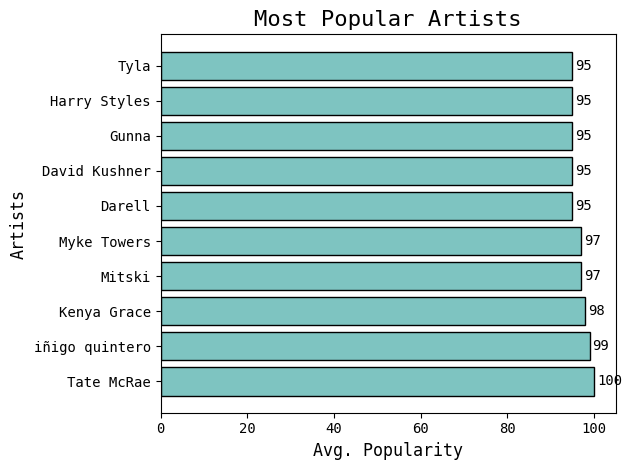

In [18]:
# set matplotlib params
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.family"] = "monospace"
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

topArtistsPopularity = df.groupby("Artist Name")["Popularity"].mean().nlargest(10)
topArtistsPopularity.astype(int)

artists = topArtistsPopularity.index
artistsPopularity = topArtistsPopularity.values

barChart = plt.barh(artists, artistsPopularity, color="#7ec4c1", edgecolor="black")
plt.bar_label(barChart, color="black", padding=2)
plt.xlabel("Avg. Popularity")
plt.ylabel("Artists")
plt.title("Most Popular Artists")
plt.tight_layout()

### Avg. Popularity over time based on year and month


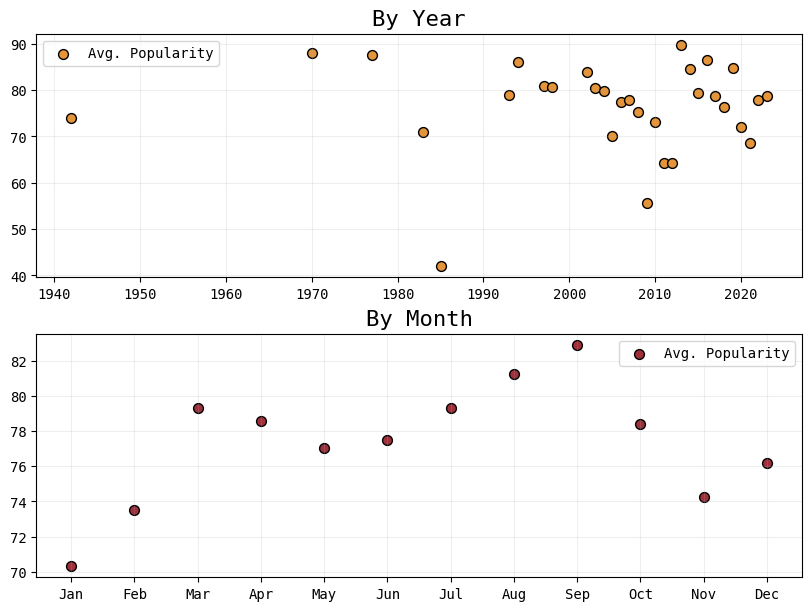

In [19]:
avgPopByYear = df.groupby([df.Year])["Popularity"].mean()
avgPopByMonth = df.groupby([df.Month])["Popularity"].mean()
avgPopByMonth.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), constrained_layout=True)

axes[0].scatter(avgPopByYear.index, avgPopByYear.values, color="#e4943a", label="Avg. Popularity", edgecolor="black", s=50)
axes[0].legend()
axes[0].grid(alpha=0.2)
axes[0].set_title("By Year")

axes[1].scatter(avgPopByMonth.index, avgPopByMonth.values, color="#9d303b", label="Avg. Popularity", edgecolor="black", s=50)
axes[1].legend()
axes[1].grid(alpha=0.2)
axes[1].set_title("By Month")
plt.show()

### What about days? Are songs released in certain days more popular?

Text(0, 0.5, 'Avg. Popularity')

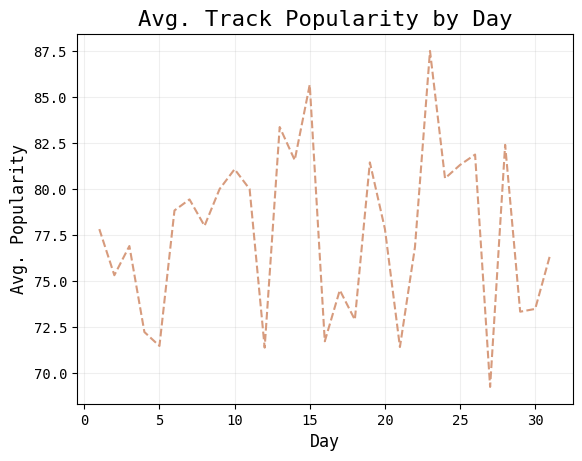

In [20]:
avg_popularity_per_day = df.groupby("Day")["Popularity"].mean()

plt.plot(avg_popularity_per_day.index, avg_popularity_per_day.values, linestyle="dashed", color="#d79b7d")
plt.grid(alpha=0.2)
plt.title("Avg. Track Popularity by Day")
plt.xlabel("Day")
plt.ylabel("Avg. Popularity")

### Danceability vs Acousticness

Text(0, 0.5, 'Avg. Acousticness')

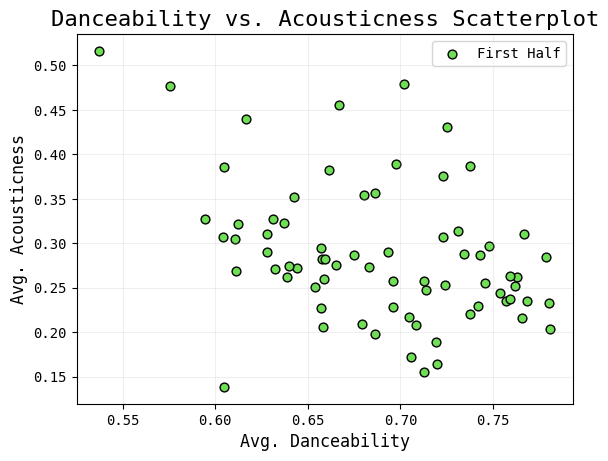

In [21]:
pivot = df.pivot_table(index="Country", values=["Danceability", "Acousticness"], aggfunc="mean")

plt.scatter(x=pivot["Danceability"], y=pivot["Acousticness"], edgecolor="black", color="#6EDE54", s=40, label="First Half")
plt.grid(alpha=0.2)
plt.legend()
plt.title("Danceability vs. Acousticness Scatterplot")
plt.xlabel("Avg. Danceability")
plt.ylabel("Avg. Acousticness")

### Popularity Stats

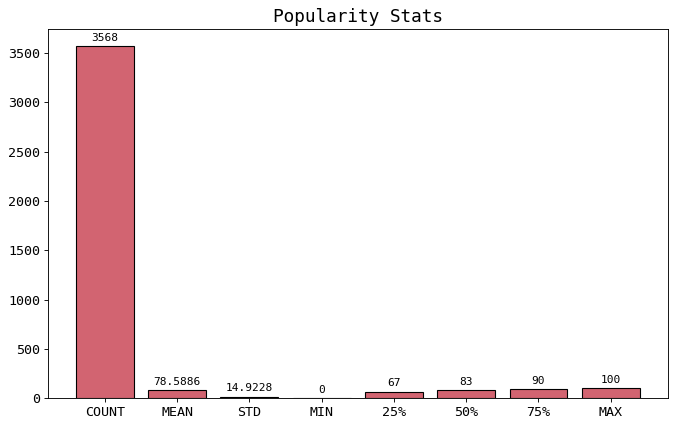

In [22]:
describeTable = df.describe(include=["number"]).astype(np.float64)

# uppercase and make some rounding
describeTable.index = [index.upper() for index in describeTable.index]
describeTable.iloc[1, 0] = round(describeTable.iloc[1, 0], 2)
describeTable.iloc[2, 0] = round(describeTable.iloc[2, 0], 2)

plt.figure(figsize=(10, 6), dpi=80)
barChart = plt.bar(describeTable["Popularity"].index, describeTable["Popularity"].values, color="#d26471", edgecolor="black")
plt.bar_label(barChart,  padding=3)
plt.title("Popularity Stats")
plt.tick_params(axis="both", labelcolor="black", labelsize=12)

### Which albums have the highest energy?


<Axes: title={'center': 'Albums with the highest Energy'}, ylabel='Album Name'>

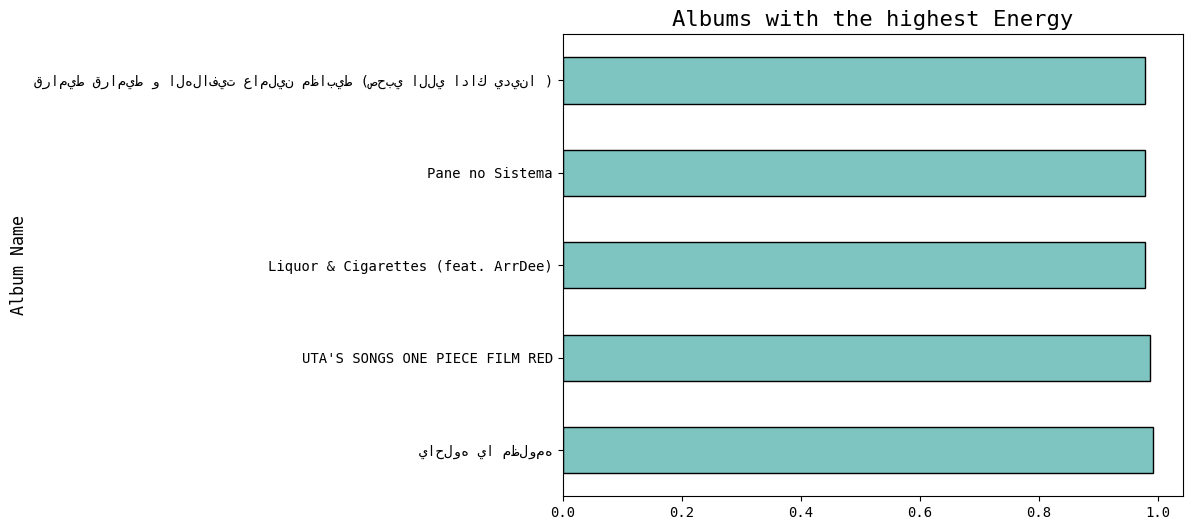

In [23]:
df.groupby("Album Name")["Energy"].mean().nlargest(5).plot(figsize=(8, 6),
    kind="barh", edgecolor="black", color="#7ec4c1", title="Albums with the highest Energy")

### Scatter plots: Danceability vs Energy, colored by Popularity.


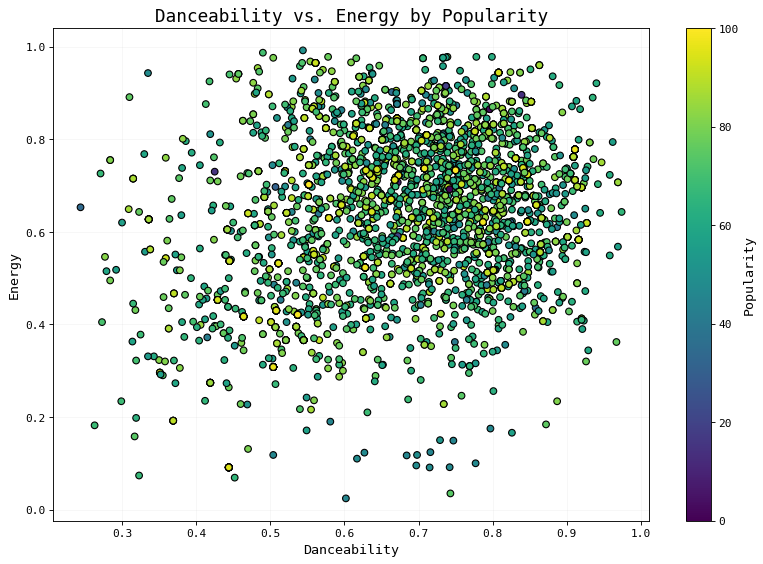

In [24]:
plt.figure(figsize=(12, 8), dpi=80)

scatterPlot = plt.scatter(df["Danceability"], df["Energy"], c=df["Popularity"], cmap="viridis", edgecolor="black")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.colorbar(scatterPlot, label="Popularity")
plt.grid(alpha=0.1)
plt.tick_params(axis="both", labelcolor="black")
plt.title("Danceability vs. Energy by Popularity")
plt.show()

### Did some years have more tracks than others?

Text(0.5, 1.0, 'Yearly Tracks Released')

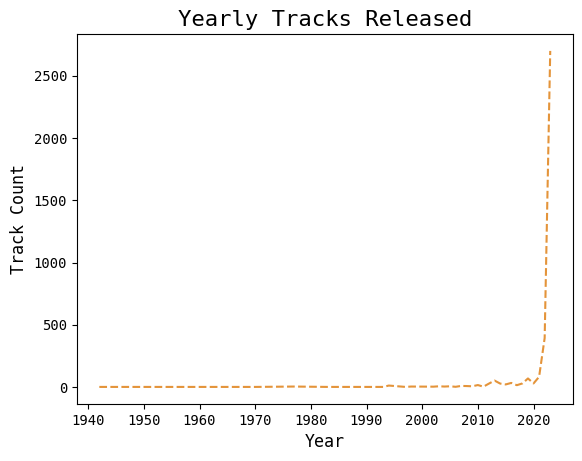

In [25]:
yearly_track_counts = df.groupby("Year")["Track Name"].size()

plt.plot(yearly_track_counts.index, yearly_track_counts.values, color="#e4943a", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Track Count")
plt.title("Yearly Tracks Released")

### Are longer tracks (in terms of length) more popular?

Text(0, 0.5, 'Popularity')

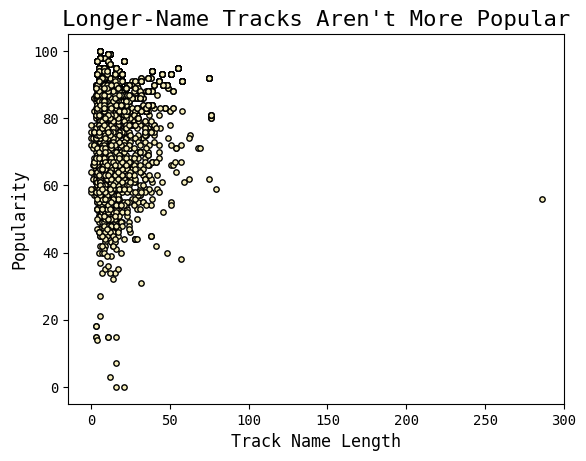

In [26]:
plt.scatter(df["Track Name Length"], df.Popularity, edgecolor="black", s=15, color="#f5edba")
plt.title("Longer-Name Tracks Aren't More Popular")
plt.xlabel("Track Name Length")
plt.ylabel("Popularity")

### Are major mode songs (mode of 1) more energetic than minor mode ones (mode of 0)?

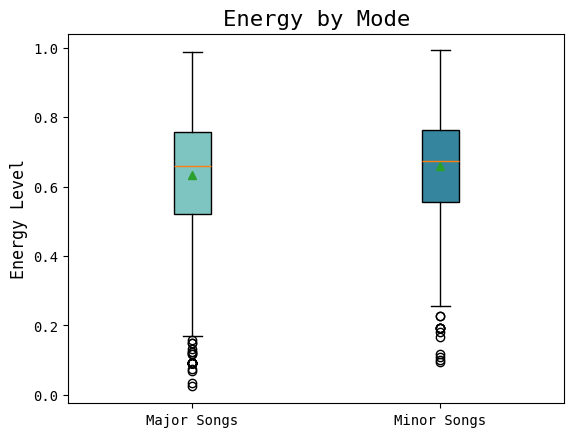

In [27]:
energy_values_major = df[df.Mode == 1]["Energy"].values
energy_values_minor = df[df.Mode == 0]["Energy"].values
boxplot_colors = ["#7ec4c1", "#34859d"]

plt.ylabel("Energy Level")
plt.title("Energy by Mode")

bPlot = plt.boxplot([energy_values_major, energy_values_minor], patch_artist=True, 
            showmeans=True, tick_labels=["Major Songs", "Minor Songs"])
plt.ylabel("Energy Level")
plt.title("Energy by Mode")

for patch, color in zip(bPlot["boxes"], boxplot_colors):
    patch.set_facecolor(color)

### Are some numeric features more correlated than others?

Text(0.5, 1.0, 'Numeric Correlations')

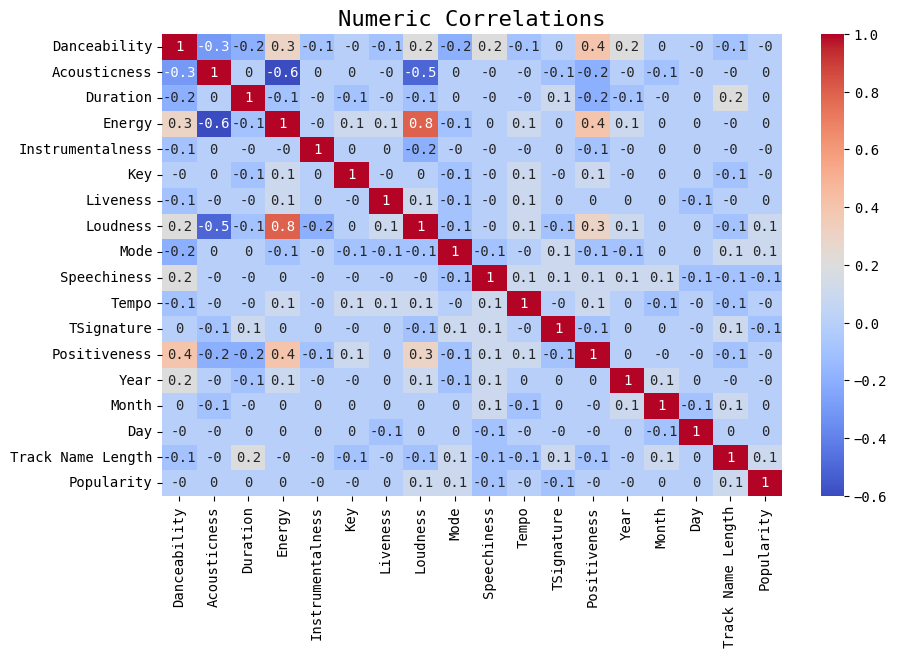

In [28]:
numeric_corrs = df.corr(method="pearson", numeric_only=True).round(1)

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_corrs, annot=True, cmap="coolwarm")
plt.title("Numeric Correlations")

## Machine Learning

### Multiple Linear Regression

In [29]:
# using numeric columns to predict popularity 
X = df.select_dtypes(include="number").drop(columns="Popularity")
y = df.Popularity

In [30]:
# split into training and test sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling for Linear Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
# don't fit on the test data because fitting on test data leaks information from the test set
X_test_scaled = scaler.transform(X_test)

In [31]:
# create model
from sklearn.linear_model import LinearRegression

regressor = LinearRegression(n_jobs=-1)
regressor.fit(X_train_scaled, y_train)

# predictions
y_pred = regressor.predict(X_test_scaled)

In [32]:
# metrics
from sklearn.metrics import mean_absolute_error

r2_train_regr = regressor.score(X_train_scaled, y_train)
r2_test_regr = regressor.score(X_test_scaled, y_test)
mae_regr = mean_absolute_error(y_test, y_pred)

print(f"Multiple Linear Regression R2 score Test: {round(r2_test_regr, 2)}")
print(f"Multiple Linear Regression R2 score Train: {round(r2_train_regr, 2)}")
print(f"Multiple Linear Regression MAE Test: {round(mae_regr, 2)}")

Multiple Linear Regression R2 score Test: 0.05
Multiple Linear Regression R2 score Train: 0.07
Multiple Linear Regression MAE Test: 12.29


Text(0, 0.5, 'Residuals')

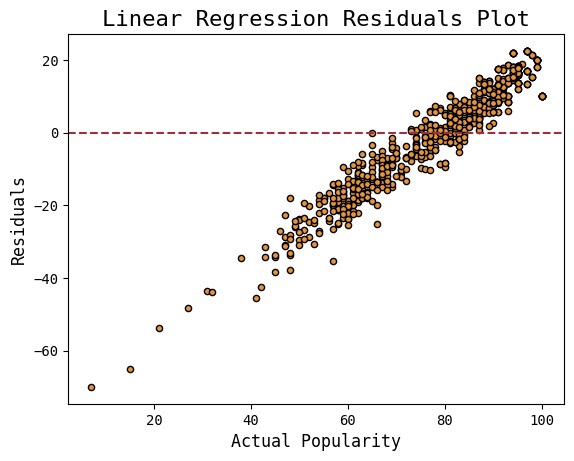

In [33]:
# residuals plot
residuals = y_test - y_pred

plt.scatter(y_test, residuals, s=20, color="#e4943a", edgecolor="black")
plt.axhline(y=0, color="#9d303b", linestyle="--")
plt.title("Linear Regression Residuals Plot")
plt.xlabel("Actual Popularity")
plt.ylabel("Residuals")

### Random Forest Regression

In [34]:
# create model
from sklearn.ensemble import RandomForestRegressor

random_forest_regr = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
random_forest_regr.fit(X_train, y_train)

# predict
y_pred_rand_forest = random_forest_regr.predict(X_test)

In [35]:
# metrics
r2_train_rand_forest = random_forest_regr.score(X_train, y_train)
r2_test_rand_forest = random_forest_regr.score(X_test, y_test)
mae_metric_rand_forest = mean_absolute_error(y_test, y_pred_rand_forest)

print(f"Random Forest Regression R2 score Train: {round(r2_train_rand_forest, 2)}")
print(f"Random Forest Regression R2 score Test: {round(r2_test_rand_forest, 2)}")
print(f"Random Forest Regression MAE Test: {round(mae_metric_rand_forest, 2)}")

Random Forest Regression R2 score Train: 0.96
Random Forest Regression R2 score Test: 0.68
Random Forest Regression MAE Test: 4.93


Text(0, 0.5, 'Residuals')

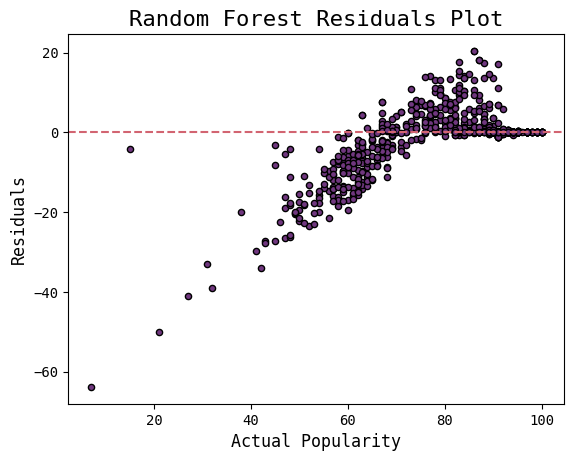

In [36]:
# residuals plot (random forest)
residuals_rand_forest = y_test - y_pred_rand_forest

plt.scatter(y_test, residuals_rand_forest, s=20, color="#70377f", edgecolor="black")
plt.axhline(y=0, color="#d26471", linestyle="--")
plt.title("Random Forest Residuals Plot")
plt.xlabel("Actual Popularity")
plt.ylabel("Residuals")

Text(0.5, 0, '%')

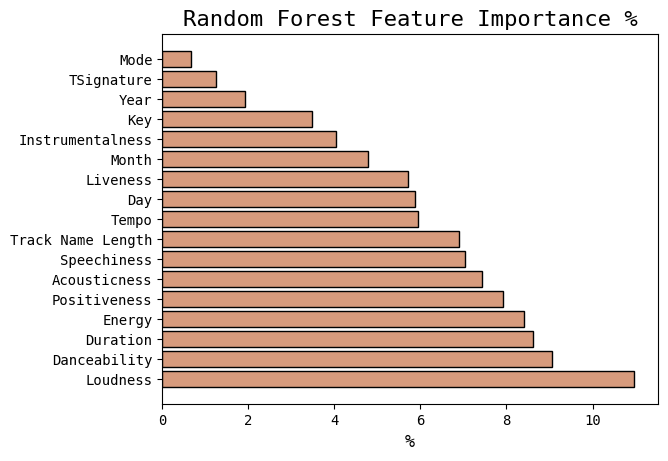

In [37]:
# feature importance
importance = pd.Series(random_forest_regr.feature_importances_, index=X.columns).sort_values(ascending=False) * 100

plt.barh(importance.index, importance.values, edgecolor="black", color="#d79b7d")
plt.title("Random Forest Feature Importance %")
plt.xlabel("%")

## Exploratory Data Analysis Conclusions

1.	Artists with the highest average track popularity in the dataset include Tate McRae, Iñigo Quintero, and Kenya Grace.
2.	Average popularity appears relatively stable across years in the dataset, although the dataset is heavily concentrated in recent releases, especially 2023. 
In terms of month, January remains, on average, the least popular. September gains the top spot instead.
3.	Danceability and acousticness show a moderate negative relationship, meaning tracks with higher danceability often have lower acousticness scores.
4.	Some highly energetic albums are UTA’S SONGS ONE PIECE FILM RED, Liquor & Cigarettes and Pane no Sistema.
5.	There aren’t many tracks that were released from ≈1940 to 2010 (range 1-16). But in 2023 tracks exploded in number to 2699. To note, majority of years are 2023, therefore meaningful conclusions can’t be drawn.
6.	No meaningful relationship was observed between track name length and popularity.
7.	Both major and minor mode songs show some low-energy outliers, while most tracks cluster around higher energy levels.

## Machine Learning Conclusions


I trained two regression models to predict Popularity using numerical features only:
1.	Multiple Linear Regression: the model itself makes simplifying assumptions, which was evidenced in both the training and test set results. The model suffers from high bias, therefore it underfits the data as seen from the poor R2 score on the test set (0.05) and training set (0.07).
Furthermore, the relatively high mean absolute error of 12.29 means that the model gets a popularity prediction wrong by 12.29, on average. The residuals plot confirms the poor performance since there are many points above/below 0.
2.	Random Forest Regression: the model achieved a stronger performance compared to linear regression. 
For one, the training set R2 score of 0.96 is almost perfect but fails short on the test set, scoring 0.68 only. The model suffers from high variance because it learns too much, overfitting the data. 
Nonetheless, the residuals are much closer to 0 compared to linear regression, demonstrating that ensemble models can generate better predictions compared to simpler models. 
Furthermore, the relatively low mean absolute error, 4.96, supports the last sentence even further. 

    Random Forest feature importance suggests that Duration, Danceability and Loudness were among the strongest predictors of popularity.